# Step09 — run and review notebook

This notebook is the **execution + QC + review** notebook for Step09.

It is designed to be consistent with the intended style for all pipeline notebooks:

1. configure paths and options
2. run the production script(s)
3. run QC script(s)
4. inspect intermediate products
5. inspect the final merged product
6. hand off cleanly to the next step

## Step09 logic

- **A1**: continuum on `OBJ_PRESKY`
- **B1**: first OH subtraction
- **A2**: continuum on `STELLAR_P1`
- **B2**: second OH subtraction on `OBJ_PRESKY` using improved continuum
- preferred = lower robust residual RMS between B1 and B2

Final merged Step09 product:

`extract1d_optimal_ridge_all_wav_ohclean.fits`

Canonical science columns added by Step09:

- `OH_MODEL`
- `STELLAR`
- `RESID_POSTOH`
- `CONTINUUM_STEP09`
- `STEP09_PREF`

In [1]:
from pathlib import Path
import os
import subprocess
import shlex
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## Configuration

Edit only this cell before running the notebook.

In [2]:
# --- repo / environment ---
REPO = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline")
PYTHON = "python"   # or full path to the environment python if needed

# --- Step08 input (authoritative input to Step09) ---
INFILE = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/08_extract1d/extract1d_optimal_ridge_all_wav.fits")

# --- Step09 working directory ---
ROOT09 = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab")

# --- one representative slit for focused QC / display ---
SLIT = "SLIT024"

# --- run controls ---
RUN_ONE_SLIT_TEST = False   # set True to run only the representative slit
RUN_ALL_SLITS = False       # set True to run the full Step09 driver
RUN_MERGE = False           # set True to run the preferred-product merge
RUN_QC_ALL = False          # set True to run the preferred-all-slits QC PDF/CSV
RUN_QC_ONE = False          # set True to run the one-slit ABAB comparison PDF

# --- script locations ---
STEP09_DRIVER = REPO / "pipeline/step09_oh_refine/step09_abab_driver.py"
STEP09_MERGE  = REPO / "pipeline/step09_oh_refine/step09e_merge_preferred.py"
QC_ONE        = REPO / "qc/step09/qc_step09_abab_compare_one_slit.py"
QC_ALL        = REPO / "qc/step09/qc_step09_preferred_all_slits.py"

# --- derived outputs ---
MERGED = ROOT09 / "extract1d_optimal_ridge_all_wav_ohclean.fits"
SUMMARY = ROOT09 / "step09_summary.csv"
QC_ALL_PDF = ROOT09 / "qc_step09_preferred_all_slits.pdf"
QC_ALL_CSV = ROOT09 / "qc_step09_preferred_all_slits_summary.csv"
QC_ONE_PDF = ROOT09 / f"qc_{SLIT}_abab_compare.pdf"

PASS1A = ROOT09 / SLIT / "step09_pass1a_continuum.fits"
PASS1B = ROOT09 / SLIT / "step09_pass1b_oh.fits"
PASS2A = ROOT09 / SLIT / "step09_pass2a_continuum.fits"
FINAL  = ROOT09 / SLIT / "step09_final_abab.fits"
PREF   = ROOT09 / SLIT / "step09_preferred.fits"

QC_MOSAIC = REPO / "qc/step09/qc_step09_final_mosaic.py"
QC_MOSAIC_PNG = ROOT09 / "qc_step09" / "all_stellar_wavelength_montage.png"
QC_MOSAIC_PDF = ROOT09 / "qc_step09" / "all_stellar_wavelength_montage.pdf"

RUN_QC_MOSAIC = True
ROOT09.mkdir(parents=True, exist_ok=True)

print("REPO   =", REPO)
print("INFILE =", INFILE, "exists =", INFILE.exists())
print("ROOT09 =", ROOT09, "exists =", ROOT09.exists())
print("SLIT   =", SLIT)

REPO   = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
INFILE = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/08_extract1d/extract1d_optimal_ridge_all_wav.fits exists = True
ROOT09 = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab exists = True
SLIT   = SLIT024


In [3]:
def run_cmd(cmd, cwd=REPO, env=None):
    if env is None:
        env = os.environ.copy()
    env["PYTHONPATH"] = "."
    print("[CMD]", " ".join(shlex.quote(str(x)) for x in cmd))
    proc = subprocess.run(
        [str(x) for x in cmd],
        cwd=str(cwd),
        env=env,
        text=True,
        capture_output=True,
    )
    print("--- STDOUT ---")
    print(proc.stdout if proc.stdout.strip() else "[empty]")
    print("--- STDERR ---")
    print(proc.stderr if proc.stderr.strip() else "[empty]")
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed with return code {proc.returncode}")
    return proc

def read_slit_table(fits_path, slit):
    with fits.open(fits_path) as hdul:
        return Table(hdul[slit].data)

def arr(tab, col):
    x = np.asarray(tab[col], float)
    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)
    return np.ravel(x)

def robust_rms(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.nanmedian(x)
    return float(np.sqrt(np.nanmedian((x - med) ** 2)))

def finite_ylim(*arrays, qlo=0.5, qhi=99.5, pad=0.08):
    vals = []
    for a in arrays:
        a = np.asarray(a, float)
        m = np.isfinite(a)
        if np.any(m):
            vals.append(a[m])
    if not vals:
        return (-1, 1)
    x = np.concatenate(vals)
    lo, hi = np.nanpercentile(x, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return (-1, 1)
    d = hi - lo
    return lo - pad * d, hi + pad * d

## Inventory before running

In [4]:
for p in [STEP09_DRIVER, STEP09_MERGE, QC_ONE, QC_ALL]:
    print(p.name, "->", p.exists())

for p in [INFILE, ROOT09]:
    print(p, "->", p.exists())

step09_abab_driver.py -> True
step09e_merge_preferred.py -> True
qc_step09_abab_compare_one_slit.py -> True
qc_step09_preferred_all_slits.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/08_extract1d/extract1d_optimal_ridge_all_wav.fits -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab -> True


## Execute Step09

Set one or more run flags to `True` in the configuration cell if you want the notebook to actually launch the production scripts.

In [5]:
if RUN_ONE_SLIT_TEST:
    run_cmd([
        PYTHON,
        STEP09_DRIVER,
        "--in-fits", INFILE,
        "--outdir", ROOT09,
        "--slit", SLIT,
    ])
else:
    print("RUN_ONE_SLIT_TEST = False  -> skipped")

RUN_ONE_SLIT_TEST = False  -> skipped


In [6]:
if RUN_ALL_SLITS:
    run_cmd([
        PYTHON,
        STEP09_DRIVER,
        "--in-fits", INFILE,
        "--outdir", ROOT09,
    ])
else:
    print("RUN_ALL_SLITS = False  -> skipped")

RUN_ALL_SLITS = False  -> skipped


In [7]:
if RUN_MERGE:
    run_cmd([
        PYTHON,
        STEP09_MERGE,
        "--root", ROOT09,
        "--out", MERGED,
    ])
else:
    print("RUN_MERGE = False  -> skipped")

RUN_MERGE = False  -> skipped


In [8]:
if RUN_QC_ALL:
    run_cmd([
        PYTHON,
        QC_ALL,
        "--root", ROOT09,
        "--out-pdf", QC_ALL_PDF,
        "--out-csv", QC_ALL_CSV,
    ])
else:
    print("RUN_QC_ALL = False  -> skipped")

RUN_QC_ALL = False  -> skipped


In [9]:
if RUN_QC_ONE:
    run_cmd([
        PYTHON,
        QC_ONE,
        "--pass1a", PASS1A,
        "--pass1b", PASS1B,
        "--pass2a", PASS2A,
        "--final", FINAL,
        "--slit", SLIT,
        "--out-pdf", QC_ONE_PDF,
    ])
else:
    print("RUN_QC_ONE = False  -> skipped")

RUN_QC_ONE = False  -> skipped


## Inventory after running

In [10]:
slit_dirs = sorted([p.name for p in ROOT09.iterdir() if p.is_dir() and p.name.startswith("SLIT")])
print("Number of slit directories:", len(slit_dirs))
print("First few:", slit_dirs[:10])
print("Last few:", slit_dirs[-10:])

for p in [SUMMARY, MERGED, QC_ALL_PDF, QC_ALL_CSV, QC_ONE_PDF]:
    print(p.name, "->", p.exists())

Number of slit directories: 62
First few: ['SLIT000', 'SLIT001', 'SLIT002', 'SLIT003', 'SLIT004', 'SLIT005', 'SLIT006', 'SLIT007', 'SLIT008', 'SLIT009']
Last few: ['SLIT052', 'SLIT053', 'SLIT054', 'SLIT055', 'SLIT056', 'SLIT057', 'SLIT058', 'SLIT059', 'SLIT060', 'SLIT062']
step09_summary.csv -> True
extract1d_optimal_ridge_all_wav_ohclean.fits -> True
qc_step09_preferred_all_slits.pdf -> True
qc_step09_preferred_all_slits_summary.csv -> True
qc_SLIT024_abab_compare.pdf -> True


## Step09 summary table

In [11]:
if SUMMARY.exists():
    df = pd.read_csv(SUMMARY)
    display(df.head())
else:
    df = None
    print("Missing:", SUMMARY)

,slit,rms_b1,rms_b2,preferred,preferred_file
0,SLIT000,0.010251,0.013884,B1,/Users/robberto/Library/CloudStorage/Box-Box/M...
1,SLIT001,0.002945,0.003301,B1,/Users/robberto/Library/CloudStorage/Box-Box/M...
2,SLIT002,0.005341,0.005545,B1,/Users/robberto/Library/CloudStorage/Box-Box/M...
3,SLIT003,0.010148,0.014616,B1,/Users/robberto/Library/CloudStorage/Box-Box/M...
4,SLIT004,0.005690,0.007387,B1,/Users/robberto/Library/CloudStorage/Box-Box/M...


In [12]:
if df is not None:
    print("Number of rows:", len(df))
    print()
    print(df["preferred"].value_counts(dropna=False))
    print()
    display(df[["rms_b1", "rms_b2"]].describe())

Number of rows: 62

preferred
B1    61
B2     1
Name: count, dtype: int64



,rms_b1,rms_b2
count,62.000000,62.000000
mean,0.009030,0.013728
std,0.008463,0.018056
min,0.002139,0.002270
25%,0.003868,0.004872
50%,0.006591,0.008539
75%,0.011325,0.014555
max,0.049338,0.105457


In [13]:
if df is not None:
    df_b2 = df[df["preferred"].astype(str).str.strip().eq("B2")]
    display(df_b2)

,slit,rms_b1,rms_b2,preferred,preferred_file
11,SLIT011,0.005854,0.005312,B2,/Users/robberto/Library/CloudStorage/Box-Box/M...


## Representative slit walkthrough

In [14]:
for p in [PASS1A, PASS1B, PASS2A, FINAL, PREF]:
    print(p.name, "->", p.exists())

step09_pass1a_continuum.fits -> True
step09_pass1b_oh.fits -> True
step09_pass2a_continuum.fits -> True
step09_final_abab.fits -> True
step09_preferred.fits -> True


In [15]:
if all(p.exists() for p in [PASS1A, PASS1B, PASS2A, FINAL, PREF]):
    t1a = read_slit_table(PASS1A, SLIT)
    t1b = read_slit_table(PASS1B, SLIT)
    t2a = read_slit_table(PASS2A, SLIT)
    tf  = read_slit_table(FINAL,  SLIT)

    lam  = arr(t1a, "LAMBDA_NM")
    obj  = arr(t1a, "OBJ_PRESKY")

    c1   = arr(t1a, "CONTINUUM_P1")
    r1   = arr(t1a, "RESID_P1")

    oh1  = arr(t1b, "OH_MODEL_P1")
    st1  = arr(t1b, "STELLAR_P1")
    rp1  = arr(t1b, "RESID_POSTOH_P1")

    c2   = arr(t2a, "CONTINUUM_P2")
    r2   = arr(t2a, "RESID_P2")

    oh2  = arr(tf, "OH_MODEL_FINAL")
    st2  = arr(tf, "STELLAR_FINAL")
    rp2  = arr(tf, "RESID_POSTOH_FINAL")
else:
    print("Representative slit products not all present yet.")

In [16]:
sel_path = ROOT09 / SLIT / "step09_selection.txt"
if sel_path.exists():
    print(sel_path.read_text())
else:
    print("Missing:", sel_path)

SLIT = SLIT024
RULE = choose lower robust RMS residual
RMS_B1 = 0.00700648
RMS_B2 = 0.01033270
DELTA_B2_MINUS_B1 = 0.00332623
PREFERRED = B1
FILE = step09_preferred.fits



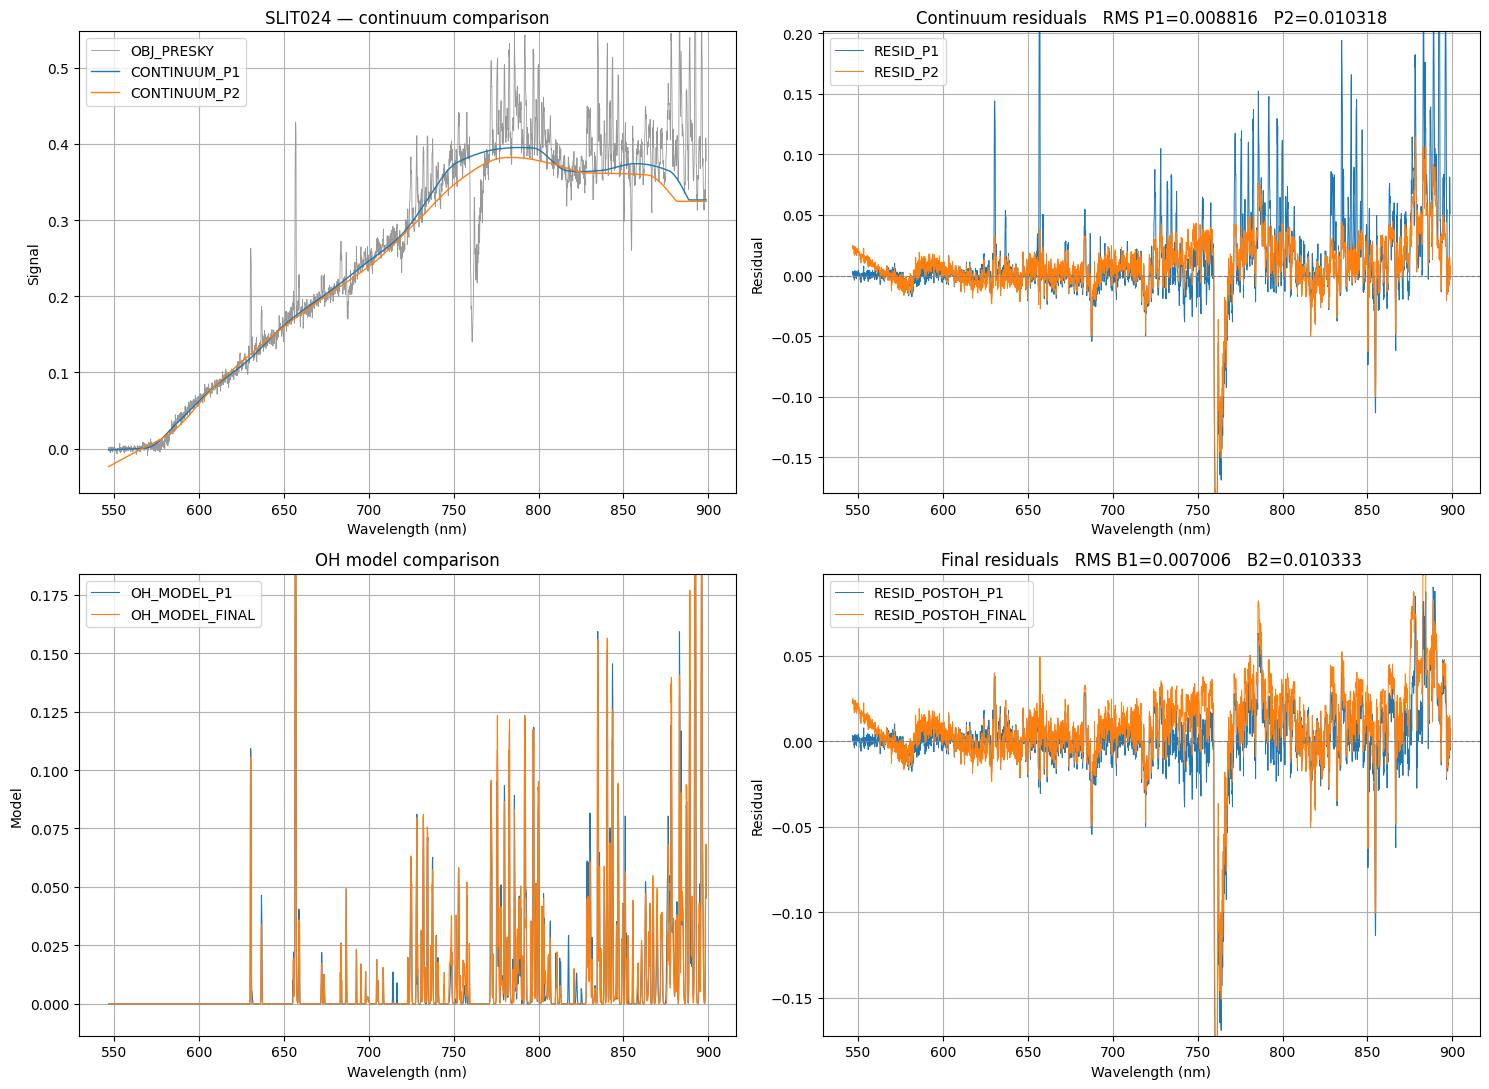

In [17]:
if all(p.exists() for p in [PASS1A, PASS1B, PASS2A, FINAL]):
    fig = plt.figure(figsize=(15, 11))

    ax = fig.add_subplot(221)
    ax.plot(lam, obj, lw=0.6, color="0.6", label="OBJ_PRESKY")
    ax.plot(lam, c1, lw=1.0, label="CONTINUUM_P1")
    ax.plot(lam, c2, lw=1.0, label="CONTINUUM_P2")
    ax.set_title(f"{SLIT} — continuum comparison")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Signal")
    ax.set_ylim(*finite_ylim(obj, c1, c2))
    ax.legend()

    ax = fig.add_subplot(222)
    ax.plot(lam, r1, lw=0.7, label="RESID_P1")
    ax.plot(lam, r2, lw=0.7, label="RESID_P2")
    ax.axhline(0, lw=0.8, ls="--", color="0.5")
    ax.set_title(f"Continuum residuals   RMS P1={robust_rms(r1):.6f}   P2={robust_rms(r2):.6f}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Residual")
    ax.set_ylim(*finite_ylim(r1, r2))
    ax.legend()

    ax = fig.add_subplot(223)
    ax.plot(lam, oh1, lw=0.8, label="OH_MODEL_P1")
    ax.plot(lam, oh2, lw=0.8, label="OH_MODEL_FINAL")
    ax.set_title("OH model comparison")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Model")
    ax.set_ylim(*finite_ylim(oh1, oh2))
    ax.legend()

    ax = fig.add_subplot(224)
    ax.plot(lam, rp1, lw=0.7, label="RESID_POSTOH_P1")
    ax.plot(lam, rp2, lw=0.7, label="RESID_POSTOH_FINAL")
    ax.axhline(0, lw=0.8, ls="--", color="0.5")
    ax.set_title(f"Final residuals   RMS B1={robust_rms(rp1):.6f}   B2={robust_rms(rp2):.6f}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Residual")
    ax.set_ylim(*finite_ylim(rp1, rp2))
    ax.legend()

    plt.tight_layout()
    plt.show()

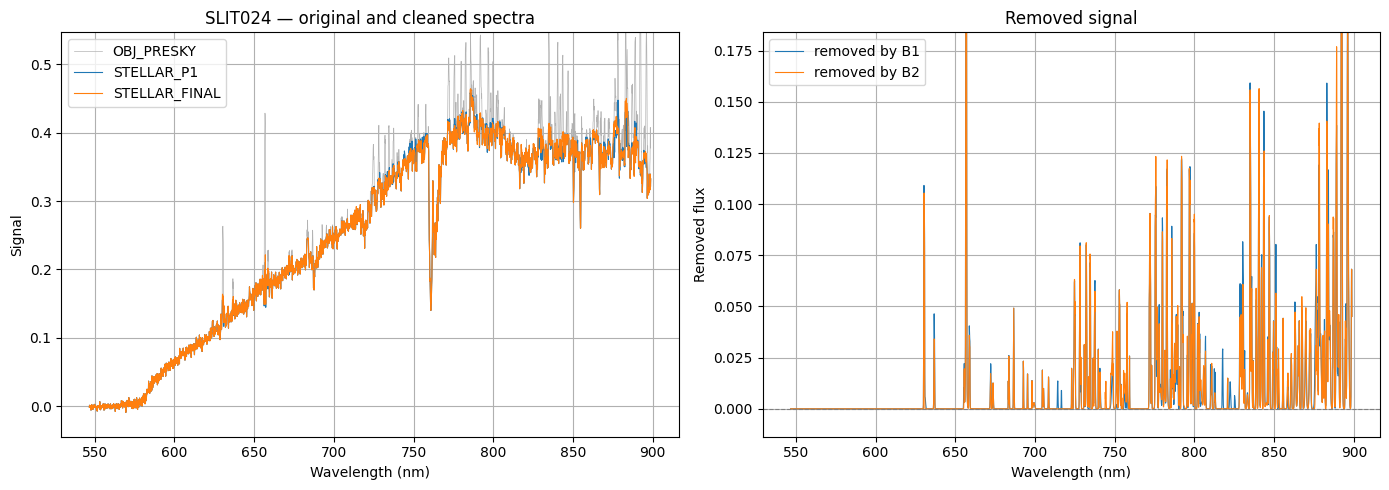

In [18]:
if all(p.exists() for p in [PASS1A, PASS1B, PASS2A, FINAL]):
    fig = plt.figure(figsize=(14, 5))

    ax = fig.add_subplot(121)
    ax.plot(lam, obj, lw=0.5, color="0.7", label="OBJ_PRESKY")
    ax.plot(lam, st1, lw=0.8, label="STELLAR_P1")
    ax.plot(lam, st2, lw=0.8, label="STELLAR_FINAL")
    ax.set_title(f"{SLIT} — original and cleaned spectra")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Signal")
    ax.set_ylim(*finite_ylim(obj, st1, st2))
    ax.legend()

    ax = fig.add_subplot(122)
    ax.plot(lam, obj - st1, lw=0.8, label="removed by B1")
    ax.plot(lam, obj - st2, lw=0.8, label="removed by B2")
    ax.axhline(0, lw=0.8, ls="--", color="0.5")
    ax.set_title("Removed signal")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Removed flux")
    ax.set_ylim(*finite_ylim(obj - st1, obj - st2))
    ax.legend()

    plt.tight_layout()
    plt.show()

## Final merged Step09 product

In [19]:
if MERGED.exists():
    with fits.open(MERGED) as h:
        print("N HDU =", len(h))
        print("First slit =", h[1].name)
        print("Last slit  =", h[-1].name)
        print()
        print("Columns in first slit:")
        print(h[1].data.names)
else:
    print("Missing:", MERGED)

N HDU = 63
First slit = SLIT000
Last slit  = SLIT062

Columns in first slit:
['YPIX', 'FLUX', 'VAR', 'SKY', 'OBJ_PRESKY', 'X0', 'NOBJ', 'NSKY', 'SKYSIG', 'APLOSS_FRAC', 'FLUX_APCORR', 'VAR_APCORR', 'EDGEFLAG', 'TRXLEFT', 'TRXRIGHT', 'LAMBDA_NM', 'OH_SHIFT_NM', 'CONTINUUM_P1', 'RESID_P1', 'CONT1', 'RESID1', 'LINE1', 'SIGNAL_CLEAN1', 'CONT2', 'RESID2', 'OH_MODEL_P1', 'STELLAR_P1', 'RESID_POSTOH_P1', 'OH_MODEL', 'STELLAR', 'RESID_POSTOH', 'CONTINUUM_STEP09', 'STEP09_PREF']


In [20]:
if MERGED.exists():
    tm = read_slit_table(MERGED, SLIT)

    lam_m = arr(tm, "LAMBDA_NM")
    obj_m = arr(tm, "OBJ_PRESKY")
    oh_m  = arr(tm, "OH_MODEL")
    st_m  = arr(tm, "STELLAR")
    rp_m  = arr(tm, "RESID_POSTOH")

    pref_raw = tm["STEP09_PREF"][0]
    pref_val = pref_raw.decode().strip() if hasattr(pref_raw, "decode") else str(pref_raw).strip()

    print("Preferred label in merged product:", repr(pref_val))

Preferred label in merged product: 'B1'


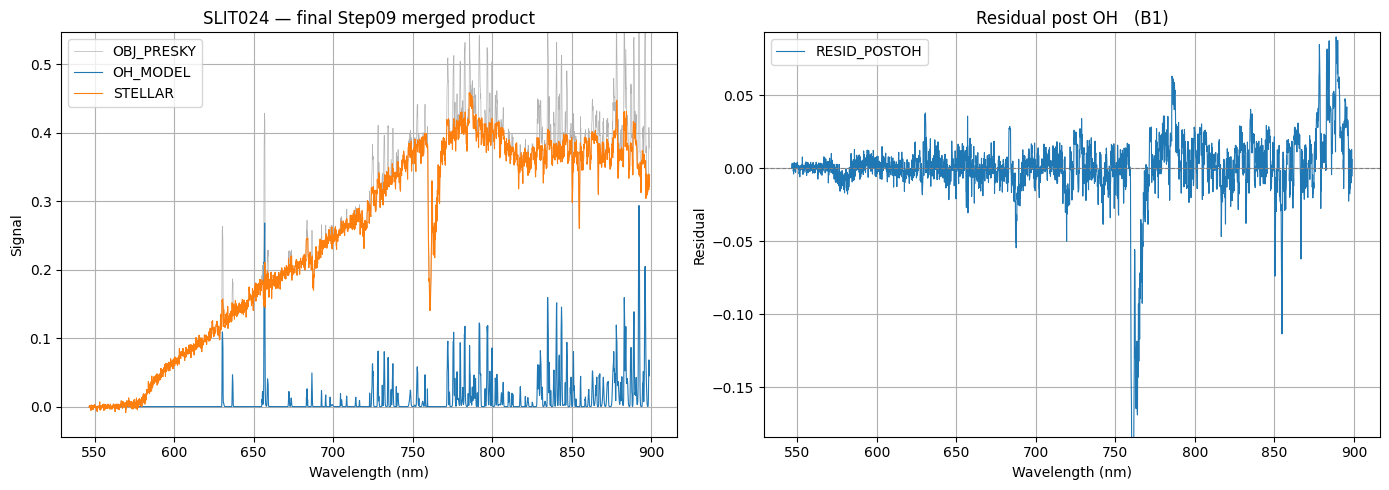

In [21]:
if MERGED.exists():
    fig = plt.figure(figsize=(14, 5))

    ax = fig.add_subplot(121)
    ax.plot(lam_m, obj_m, lw=0.5, color="0.7", label="OBJ_PRESKY")
    ax.plot(lam_m, oh_m,  lw=0.8, label="OH_MODEL")
    ax.plot(lam_m, st_m,  lw=0.8, label="STELLAR")
    ax.set_title(f"{SLIT} — final Step09 merged product")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Signal")
    ax.set_ylim(*finite_ylim(obj_m, oh_m, st_m))
    ax.legend()

    ax = fig.add_subplot(122)
    ax.plot(lam_m, rp_m, lw=0.8, label="RESID_POSTOH")
    ax.axhline(0, lw=0.8, ls="--", color="0.5")
    ax.set_title(f"Residual post OH   ({pref_val})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Residual")
    ax.set_ylim(*finite_ylim(rp_m))
    ax.legend()

    plt.tight_layout()
    plt.show()

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step09/qc_step09_final_mosaic.py' --infile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab/extract1d_optimal_ridge_all_wav_ohclean.fits' --outdir '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab/qc_step09' --column STELLAR --show-pref
--- STDOUT ---
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab/qc_step09/all_stellar_wavelength_montage.png
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2

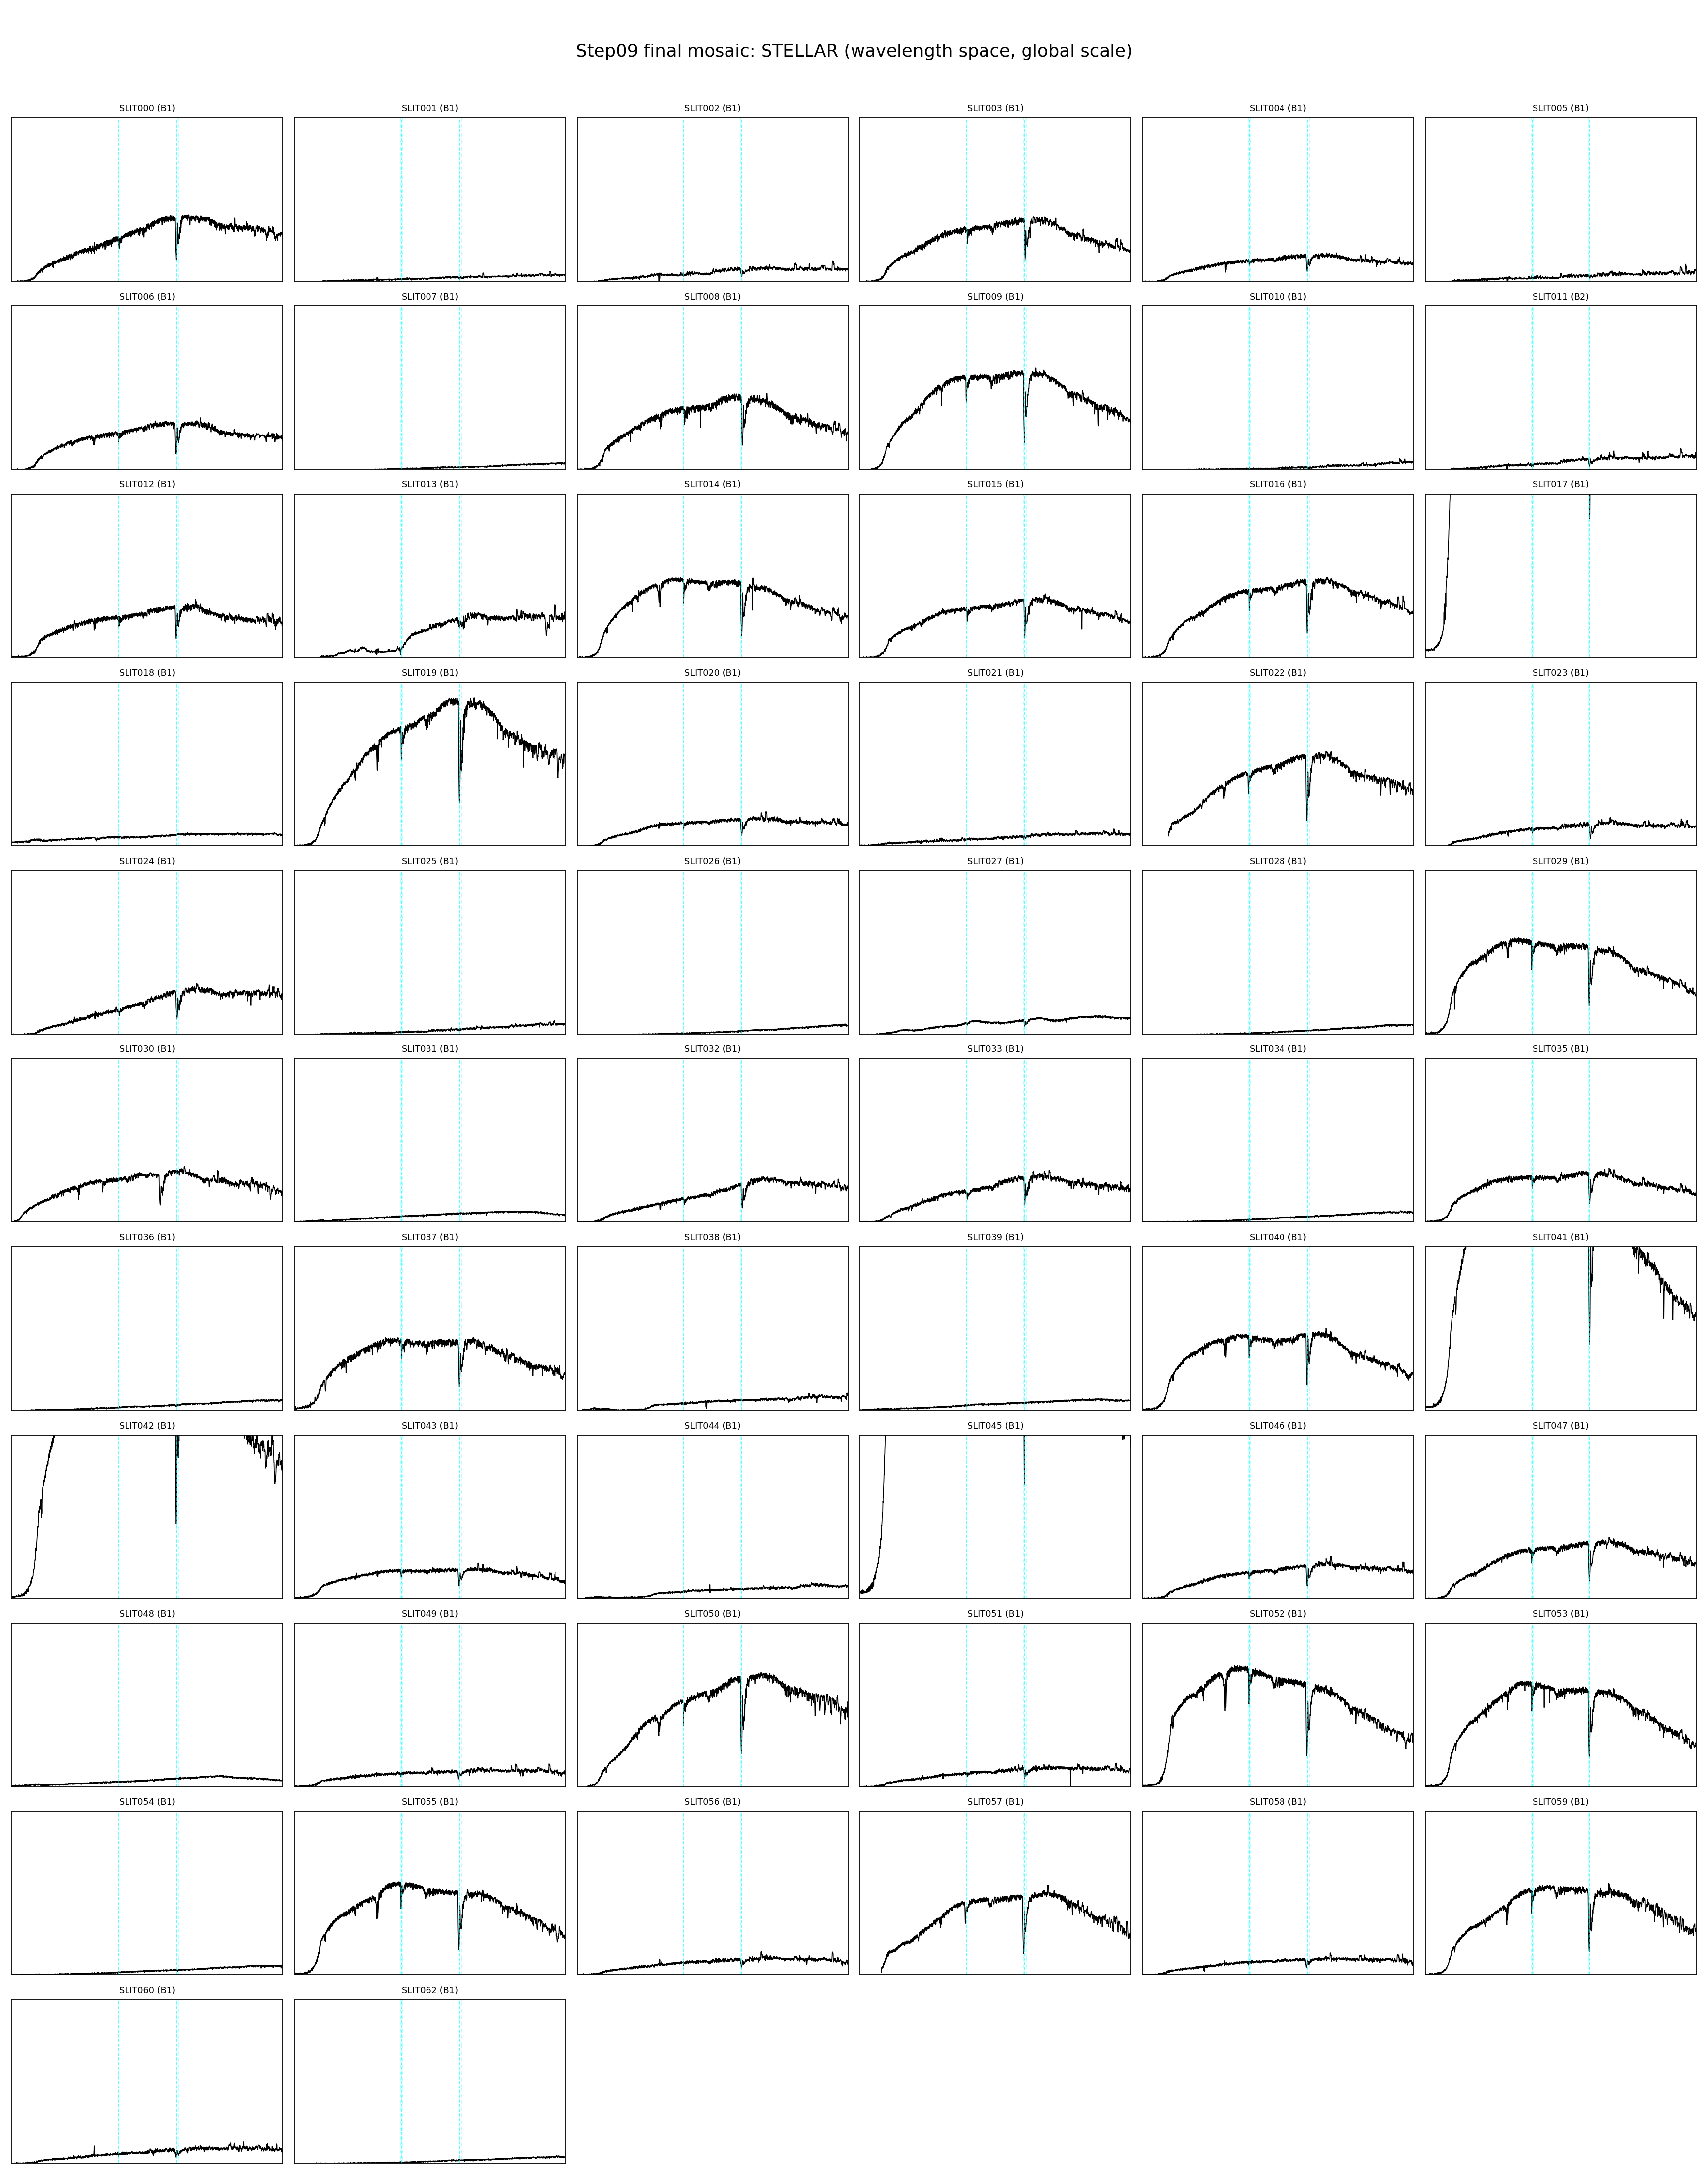

In [23]:
if RUN_QC_MOSAIC:
    run_cmd([
        PYTHON,
        QC_MOSAIC,
        "--infile", MERGED,
        "--outdir", ROOT09 / "qc_step09",
        "--column", "STELLAR",
        "--show-pref",
    ])
    from IPython.display import Image, display
    display(Image(filename=ROOT09 / "qc_step09" / "all_stellar_wavelength_montage.png"))
else:
    print("RUN_QC_MOSAIC = False  -> skipped")
    

## QC products

In [24]:
for p in [QC_ALL_PDF, QC_ALL_CSV, QC_ONE_PDF, QC_MOSAIC_PNG, QC_MOSAIC_PDF]:
    print(p.name, "->", p.exists())
    

qc_step09_preferred_all_slits.pdf -> True
qc_step09_preferred_all_slits_summary.csv -> True
qc_SLIT024_abab_compare.pdf -> True
all_stellar_wavelength_montage.png -> True
all_stellar_wavelength_montage.pdf -> True


In [25]:
print("Step09 status")
print("-------------")
print("ABAB slit directories:", len(slit_dirs))
print("Merged science product exists:", MERGED.exists())
print("Summary CSV exists:", SUMMARY.exists())
print("QC all-slits PDF exists:", QC_ALL_PDF.exists())
print("QC one-slit PDF exists:", QC_ONE_PDF.exists())

if 'df' in globals() and df is not None:
    print()
    print("Preferred counts:")
    print(df["preferred"].value_counts(dropna=False))

Step09 status
-------------
ABAB slit directories: 62
Merged science product exists: True
Summary CSV exists: True
QC all-slits PDF exists: True
QC one-slit PDF exists: True

Preferred counts:
preferred
B1    61
B2     1
Name: count, dtype: int64


## Handoff to Step10

Step10 should consume:

- wavelength = `LAMBDA_NM`
- cleaned science spectrum = `STELLAR`

Optional diagnostics available from Step09:

- `OH_MODEL`
- `RESID_POSTOH`
- `STEP09_PREF`